In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Activity 1 Solution


# Step 1: Load the dataset
df = pd.read_csv("../data/handling_anomalies_activity.csv")

In [15]:
# Step 2: Display the first and last five rows
print("\nFIRST 5 ROWS")
print(df.head())


FIRST 5 ROWS
   Record_ID  Transaction_Value
0          1             116.24
1          2              93.88
2          3              94.72
3          4              89.27
4          5             108.65


In [6]:
print("\nLAST 5 ROWS")
print(df.tail())


LAST 5 ROWS
    Record_ID  Transaction_Value
43         44               60.0
44         45              200.0
45         46              220.0
46         47               15.0
47         48               10.0


In [7]:
# Step 3: Display descriptive statistics
print("\nDESCRIPTIVE STATISTICS")
print(df.describe())


DESCRIPTIVE STATISTICS
       Record_ID  Transaction_Value
count      48.00          48.000000
mean       24.50         100.190625
std        14.00          32.330544
min         1.00          10.000000
25%        12.75          91.467500
50%        24.50          97.415000
75%        36.25         108.740000
max        48.00         220.000000


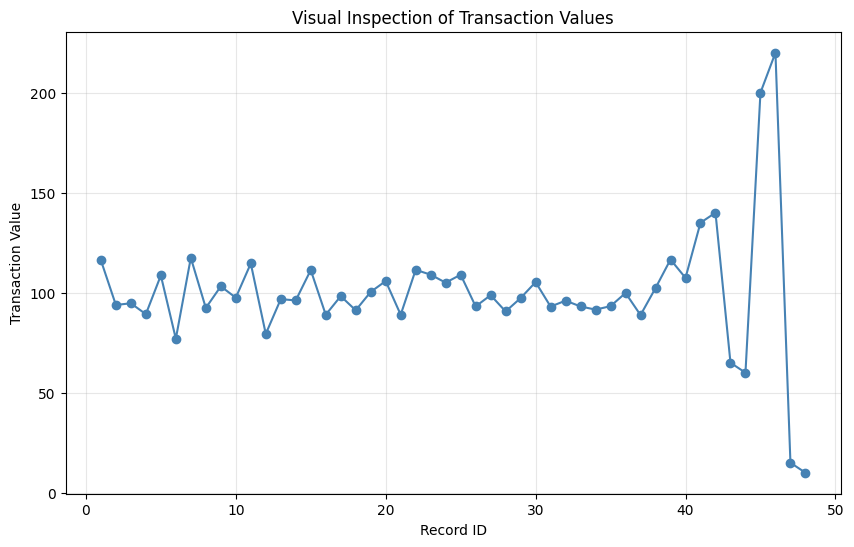

In [8]:
# Step 4: Visualise the dataset
plt.figure(figsize=(10,6))

plt.plot(df["Record_ID"],
         df["Transaction_Value"],
         marker='o',
         linestyle='-',
         color='steelblue',
         label='Transaction Value')

plt.xlabel("Record ID")
plt.ylabel("Transaction Value")
plt.title("Visual Inspection of Transaction Values")
plt.grid(alpha=0.3)


/tmp/ipykernel_16403/2803316001.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


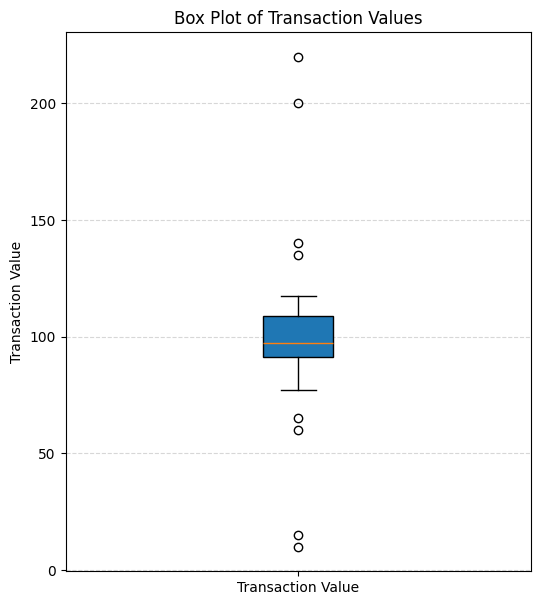

In [9]:
# Visualisation 2: Box Plot


plt.figure(figsize=(6, 7))

plt.boxplot(
    df["Transaction_Value"],
    vert=True,
    patch_artist=True,
    labels=["Transaction Value"]
)

plt.title("Box Plot of Transaction Values")
plt.ylabel("Transaction Value")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

/tmp/ipykernel_16403/3534914763.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


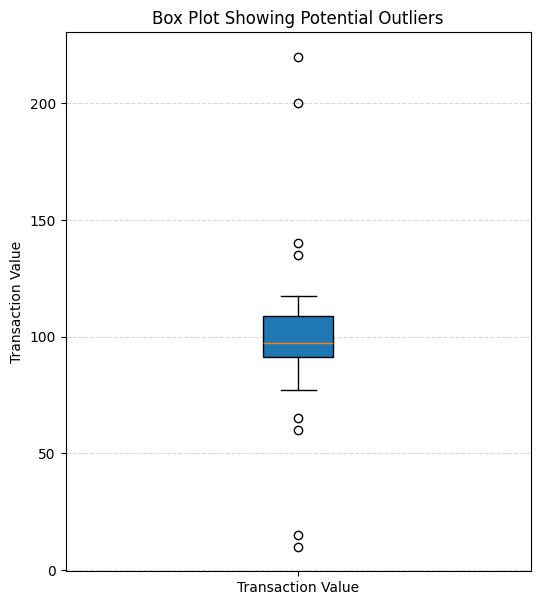

In [13]:
# Box Plot with Outliers

plt.figure(figsize=(6, 7))

plt.boxplot(
    df["Transaction_Value"],
    vert=True,
    patch_artist=True,
    labels=["Transaction Value"],
    showfliers=True
)

plt.title("Box Plot Showing Potential Outliers")
plt.ylabel("Transaction Value")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

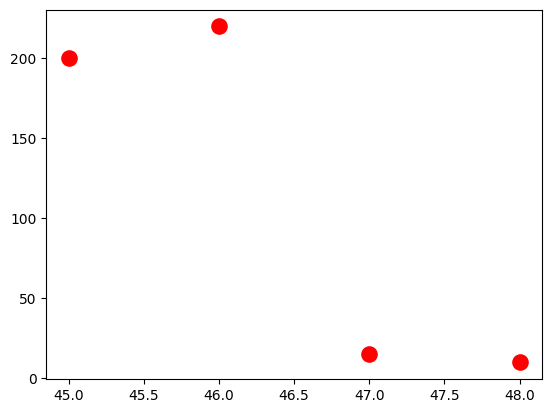

In [10]:

# Identify obvious outliers using a simple threshold
# (Advanced techniques will be covered later in the workshop)

threshold_high = 180
threshold_low = 20

outliers = df[
    (df["Transaction_Value"] > threshold_high) |
    (df["Transaction_Value"] < threshold_low)
]

# Highlight outliers
plt.scatter(
    outliers["Record_ID"],
    outliers["Transaction_Value"],
    color="red",
    s=120,
    label="Potential Outliers"
)


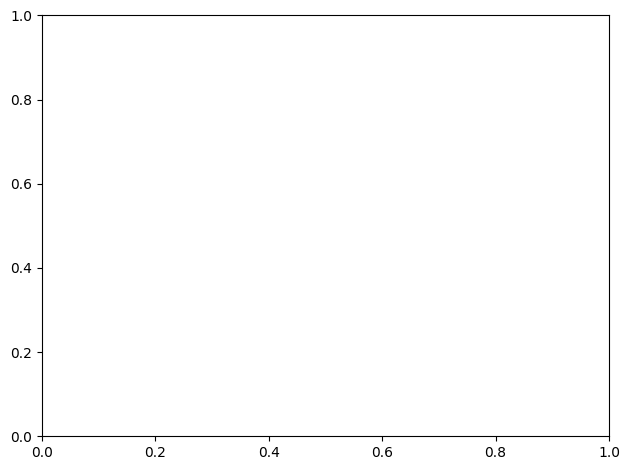

In [11]:
# Annotate each detected outlier
for _, row in outliers.iterrows():
    plt.annotate(
        str(row["Transaction_Value"]),
        xy=(row["Record_ID"], row["Transaction_Value"]),
        xytext=(row["Record_ID"] + 0.5, row["Transaction_Value"] + 10),
        arrowprops=dict(
            arrowstyle="->",
            color="red",
            linewidth=2
        ),
        fontsize=9,
        color="red"
    )

# Show legend only if labelled objects exist
handles, labels = plt.gca().get_legend_handles_labels()
if labels:
    plt.legend()

plt.tight_layout()
plt.show()

In [12]:
# Step 5: Display detected outliers
print("\n========== POTENTIAL OUTLIERS ==========")

if len(outliers) > 0:
    print(outliers)
else:
    print("No obvious outliers were found.")


========== POTENTIAL OUTLIERS ==========
    Record_ID  Transaction_Value
44         45              200.0
45         46              220.0
46         47               15.0
47         48               10.0


## INTERPRETATION
#### 4 potential outliers were identified.

These observations are considerably different from the majority of the data.

The unusually high transaction values may represent large purchases, fraudulent transactions, or data-entry mistakes.

The unusually low transaction values may represent refunds, test transactions, or recording errors.

Further investigation is required before removing these observations.